# Introduction to Image classification with CNN and CIFAR 10 dataset

This exercise introduces Convolutional Neural Networks for image classification.  In contrast to the Remote Sensing field, image classification in Computer Vision aims at generating one label for the entire image i.e. to classify an entire image into different categories. We use a neural network architecture that uses convolutional layers to extract features using learned weights in filters.

The final output of the model is a series of probabilities (activation scores) with dimension matching the number of classes/labels. For each image, the highest probability is taken as the label/class.

## Dataset

CIFAR 10 is an image dataset commonly used as a reference/baseline dataset in Machine Learning. It is produced by the Canadian Center for Advanced Research. It consists of set of 60,000 images of 10 classes of color images of size 32x32x3. The classes are common objects or animals. For instance, class 4 corresponds cats while class 2 corresponds to automobiles. The images are coarsened colors with Red, Blue, Green chanels. Of the 60,000 images, 50,000 are reserved for training while 10,000 are reserved for testing.

## Interesting Links
- lenet architecture: http://yann.lecun.com/exdb/lenet/

- lenet5: https://towardsdatascience.com/understanding-and-implementing-lenet-5-cnn-architecture-deep-learning-a2d531ebc342

- cross entropy loss: https://gombru.github.io/2018/05/23/cross_entropy_loss/

- pytorch tutorial: https://pytorch.org/tutorials/beginner/basics/data_tutorial.html





# Documentation and packages

First, we set up the code by providing information on the Authors, Creation dates, version by importing relevant python packages. Documenting and providing context and information within a script is important as it is often the case that code will be reused for other applications or other users/colleagues Good documentation improves code reproducibility as well.



In [1]:

import matplotlib.pyplot as plt

import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib import colors
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import torch
import torchvision
import torchvision.transforms as transforms

import subprocess
import pandas as pd
import os, glob
import numpy as np

np.set_printoptions(suppress=True) #suppress scientific notation
pd.set_option('display.float_format', lambda x: '%.4f' % x) #dispaly with four decimal


In [2]:
#Used in defining functions
from typing import List, Tuple, Dict, Any
from pandas.core.arrays import boolean

Check which torch version is installed in Colab

In [3]:
torch.__version__

'2.5.1+cu124'

The list of packages above constains some of the most common packages used in data science, deep learning.  In this exercise, we use matplotlib and seaborn to make graphs, plots and visualize images. Keras is used in creating the deep learning model. Sklearn provides many functionalities and methods (SVM, random forest etc.) for Machine Learning.

#Functions

In [4]:
def create_dir_and_check_existence(path: str)->str:
    '''
    Create output directory

    :param path: path to output directory
    :return: message string
    '''
    try:
        os.makedirs(path)
        message_string = "directory created"
    except:
        message_string = "directory already exists"
    return message_string

from typing import Callable, Any, Iterable, List, Tuple


def generate_accuracy_assessment(model: Any,
                      y_test: np.array,
                      x_test: np.array,
                      data_dataloader: torch.utils.data.DataLoader=None,
                      class_names: str =None)->pd.DataFrame:

  """
  Function to predict and generate accuracy metrics (precision and recall) for each model given input x and y test.

  :param model: keras model or pytorch model
  :param y_test: Input target for test, can be None if included in data_dataloader
  :param y_train: target train labels used in classification, can be None if included in data_dataloader
  :param data_dataloader: torch data loader
  :param class_names: labels for the class predicted

  :return report_df: pandas data frame with accuracy metrics

  """

  if isinstance(model, nn.Module):
    list_df_pred = []
    model.eval() # Set model to avaluation mode
    test_loss = 0.0
    for batch_val, data in enumerate(data_dataloader):
      inputs, labels = data
      # Zero the gradients
      # Forward pass
      with torch.inference_mode():
        y_score_logits = model(inputs)
        y_scores = nn.Softmax(dim=1)(y_score_logits) #these are the proba
        y_pred_test = torch.argmax(y_scores, dim=1)  # Returns [1, 2]
        #pred_class_name = class_names[y_pred_test]
        df_pred_val = pd.DataFrame(y_scores.detach().numpy())
        df_pred_val['y_pred_test'] = y_pred_test
        df_pred_val['labels'] = labels
        #df_pred_val['class_name'] = class_names[y_pred_test]
        list_df_pred.append(df_pred_val)
        y_pred_test_df = pd.concat(list_df_pred)
        model_name = model.name
        num_total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        #pytorch_total_params
  else:
    # we can store the array in a data.frame and get the max
    y_score = model.predict(x_test)
    #y_score.shape
    y_pred_test_df = pd.DataFrame(y_score)
    y_pred_test_df['y_pred_test'] = y_pred_test_df.idxmax(axis = 1) #one to go across the column for each row
    #y_pred_test_df
    model_name = model._name
    num_total_params = model.count_params()

  #let's compute the confusion matrix

  y_pred_test = y_pred_test_df['y_pred_test']
  if y_test is None:
    y_test = y_pred_test_df['labels']
  report_dict=classification_report(y_test,
                                      y_pred_test,
                                      target_names=class_names,
                                      output_dict=True)
  report_df = pd.DataFrame(report_dict)
  #confusion_matrix_val = confusion_matrix(y_test,y_pred_test)  #not in use here
  #display(report_df)
  report_df = (report_df.drop(columns=['macro avg','weighted avg'])
                        .drop(labels=['f1-score','support'])
                        .assign(model_name= lambda x: model_name)
                        .assign(num_param= lambda x: num_total_params)
                        .reset_index()
                        .rename(columns={'index':'metric'})
              )

  return report_df,y_pred_test_df


In [5]:
def train_model(model,epochs,train_dataloader):

  #took 10 minutes for 30 epochs

  #seed_value = 42
  #torch.manual_seed(seed_value) #for training reproducibiligy
  #np.random.seed(seed_value) #for GPU and CPU operations reproducibliy

  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

  # 4. Training loop
  #epochs = 30
  train_loss_list = []
  list_df_train_loss = []
  list_df_loss = []
  list_batch_number = []
  for epoch in range(epochs):
    model.train(True) # Set model to training mode
    train_loss = 0.0
    for batch_val, data in enumerate(train_dataloader):
      inputs, labels = data
      # Zero the gradients
      optimizer.zero_grad()
      # Forward pass
      outputs = model(inputs)
      # Calculate loss
      loss = loss_fn(outputs, labels)
      # Backward pass and optimization
      loss.backward()
      optimizer.step() #update the weights
      train_loss  += loss.item()
      df_loss_val = pd.DataFrame({'batch_number':[batch_val],
                              'loss':[loss.item()],
                              'epoch': [epoch]})
      list_df_loss.append(df_loss_val)

    df_train_loss_val = pd.DataFrame({'train_loss':[train_loss],
                                  'epoch': [epoch]})
    train_loss_list.append(train_loss)
    list_df_train_loss.append(df_train_loss_val)
    #print(f'Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}')
    #list_df_train_loss
    print(f'Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}')
  #maybe add validation
  df_train_loss = pd.concat(list_df_train_loss)
  df_loss = pd.concat(list_df_loss).reset_index(drop=True)
  #df_train_loss
  #df_loss

  return df_train_loss,df_loss,model


In [6]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


# Parameters and Arguments

It is good practice to set all parameters and input arguments at the beginning of the script. This allows for better control and can make modifications of the scripts for other applications easier. Some arguments relate to path directories, input files and general parameters for use in the analyses (e.g. proportion of hold out).

In [7]:
############################################################################
#####  Parameters and argument set up ###########

#ARG 1
in_dir = out_dir = "/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_to_CNN/data"
#ARG 5ntent/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_to_CNN/data/'
#ARG 2
out_dir = "/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_to_CNN"

#ARGS 3:
create_out_dir = True #create a new ouput dir if TRUE
#ARG 4
out_suffix = "intro_to_cnn_pytorch_20250301"
NA_value = -9999 # currently not used: Nan value
#ARG 6
random_seed=42 #not yet used

## Input data
#ARG 7-8
run_model = True #Retrain model if True
model_path = '/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_to_CNN/models/models_20250218'

In [8]:
################# START SCRIPT ###############################

######### PART 0: Set up the output dir ################

#set up the working directory
#Create output directory

if create_out_dir==True:
    out_dir_new = "output_data_"+out_suffix
    out_dir = os.path.join(out_dir,"outputs",out_dir_new)
    create_dir_and_check_existence(out_dir)
    os.chdir(out_dir)        #set working directory
else:
    os.chdir(out_dir) #use working dir defined earlier


In [9]:
print(out_dir)

/content/gdrive/MyDrive/Colab Notebooks/deep_learning_with_satellite_and_geospatial_data_course/intro_to_CNN/outputs/output_data_intro_to_cnn_pytorch_20250301


# Workflow/pipeline

In this exercise, we will perform the analysis using a workflow that may be succintly described using the following steps:
1. **Visualization and exploration of data**
- Obtain data from Pytorch
-Visualize feature images and target value.
- Explore if data is balanced
2. **Data processing**
- change image data type
- rescale image values
- change label to one hot encoding
3. **Exploring Convolutional layers**
- instantiate a conv2d layers in pytorch
- passing an image through a conv2d layer
- understanding image output size, padding and stride
4. **Build and train model**
- build pytorch models
- fit and train models
5. **Accuracy Assessment**
- use test data to generate an accuracy assessment
- assess accuracy using precision and recall.
6. **Conclusions**



#1.Visualization and exploration of the Dataset

We will first load the dataset using the torchvision.dataset API. Pytorch provides the CIFAR dataset already split into training and testing data. The input feature data is an RGB image of 10 different classes while the target is the label of the image.
The data loaded is in numpy format and we can check the size of the training and testing data below:

https://medium.com/@saitejamummadi/deep-dive-into-image-classification-with-pytorch-a-cifar-10-tutorial-4151f9c4c71

https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

In [10]:
train_dataset = torchvision.datasets.CIFAR10(os.path.join(out_dir,'data'), train=True, download=True, transform=transforms.ToTensor())
classes = {'plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'}
print(type(train_dataset))
print(len(train_dataset))
train_dataset.filename

Files already downloaded and verified
<class 'torchvision.datasets.cifar.CIFAR10'>
50000


'cifar-10-python.tar.gz'

In [11]:
!ls -ltr data/

total 166507
drwx------ 2 root root      4096 Jun  4  2009 cifar-10-batches-py
-rw------- 1 root root 170498071 Mar  1 01:30 cifar-10-python.tar.gz


In [12]:
!ls -ltr data/cifar-10-batches-py/data_batch_1

-rw------- 1 root root 31035704 Mar 31  2009 data/cifar-10-batches-py/data_batch_1


The train pytorch dataset object contains 50,000 images. We can select a specific image from the dataset object by accessing the data attribute.

In [13]:
print(type(train_dataset.data))
print(train_dataset.data.shape)
print(len(train_dataset))
print(train_dataset.data[0].shape)

<class 'numpy.ndarray'>
(50000, 32, 32, 3)
50000
(32, 32, 3)


We can explore the dataset by plotting an image and checking the class names. These are accessible via the data and classes attributes.

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
<class 'torchvision.datasets.cifar.CIFAR10'>
(32, 32, 3)
<class 'numpy.ndarray'>


Text(0.5, 1.0, 'Class number is :6')

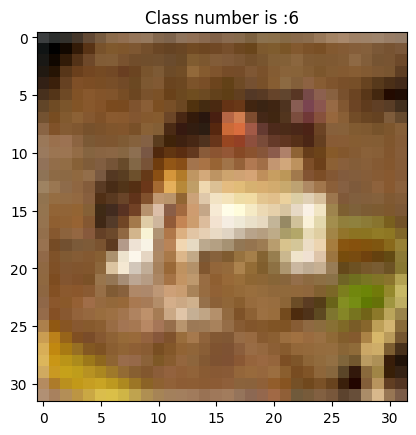

In [14]:
print(train_dataset.classes)
print(type(train_dataset)) #check that the data type is torch vision dataset
print(train_dataset.data[0].shape) #selecting sample 0
print(type(train_dataset.data[0])) #type of sample 0: stored as numpy array
plt.imshow(train_dataset.data[0])
plt.title(f'Class number is :{train_dataset.targets[0]}')

Let's explore the first 10 images with labels. Print figure with 10 random images from each class..

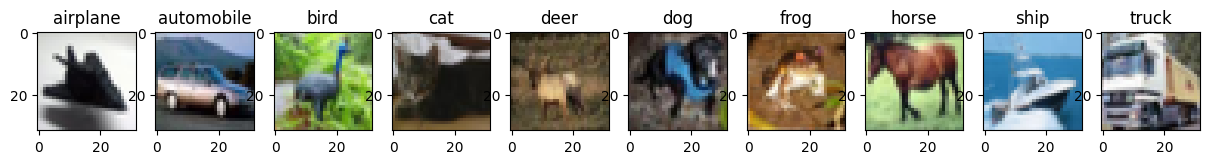

In [15]:

num_classes=10
class_names = train_dataset.classes
#fig = plt.figure(figsize=(8,3))
f, ax = plt.subplots(1,num_classes,figsize=(15,15))

for class_val in range(num_classes):

    #class_index = np.where(y_train[:]==class_val)[0] #returns tuple because it is a two dimensional array
    class_index = np.where(np.array(train_dataset.targets) == class_val)[0][0] #returns tuple because it is a two dimensional array

    #take first element matching the class as it is relevant to the class
    image = train_dataset.data[class_index]
    #print("Image size",image.shape)
    ax[class_val].imshow(image)
    ax[class_val].set_title(class_names[class_val])

#2.Data Processing, dataset and dataset loader

The input data comes as byte for each of the channels. This means that it is within the 0 to 255 range. Neural Networks and deep learning model converge faster when values are within the 0-1 range . We will process the data to prepare the inputs for the model in 3 steps:

- change data type for images
- change scale to 0-1
- change label to one hot encoding

links:
https://pytorch.org/vision/main/generated/torchvision.transforms.ToTensor.html


In [16]:
print(train_dataset.data.dtype) #byte
print(train_dataset.data.min())
print(train_dataset.data.max())
print(type(train_dataset.data[0]))

uint8
0
255
<class 'numpy.ndarray'>


First we need to convert the data type from integer to float. We could do it manually and reassign values directly:


In [17]:
# change data type to float
train_dataset.data[0].astype(np.float32)
# scale between 0 and 1
train_dataset.data[0]/255

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

It is better however to use the functionality provided by pytorch in particular, the transforms module. This module allows for the composition of a sequence of transformation applied to images in a pytorch dataset. For example, below we use the 'ToTensor()' operation in a transforms object to change the data type of input images to float and rescale to 0-1 range. Note that ToTensor specifically expect RGB or multiband color images as inputs. Take a look at the documentation for more explanations.

In [18]:
from torchvision import transforms
transform = transforms.Compose([transforms.ToTensor()])
transform(train_dataset.data[0])

tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
         [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
         [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
         ...,
         [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
         [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
         [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

        [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
         [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
         [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
         ...,
         [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
         [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
         [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

        [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
         [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
         [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0.

Let's now declare training, testing datasets using the transform. We also create a dataloader object from the dataset object to load/fetch data during training/testing.

https://medium.com/@sergioalves94/deep-learning-in-pytorch-with-cifar-10-dataset-858b504a6b54

In [19]:
#torch.manual_seed(43)
from torch.utils.data import random_split
val_size = int(len(train_dataset)*0.1)
print(val_size)
train_size = len(train_dataset) - val_size

train_ds, val_ds = random_split(train_dataset, [train_size, val_size])
print(type(train_ds.dataset))
print(type(val_ds.dataset))
print(type(train_ds))
len(train_ds), len(val_ds)

5000
<class 'torchvision.datasets.cifar.CIFAR10'>
<class 'torchvision.datasets.cifar.CIFAR10'>
<class 'torch.utils.data.dataset.Subset'>


(45000, 5000)

In [20]:
transform = transforms.Compose([transforms.ToTensor()])

transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 128

train_dataset = torchvision.datasets.CIFAR10(os.path.join(out_dir,'data'),
                                             train=True,
                                             download=True,
                                             transform=transform)
train_ds, val_ds = random_split(train_dataset, [train_size, val_size])
#train_dataset = train_ds.dataset
#val_dataset = val_ds.dataset

train_dataloader = torch.utils.data.DataLoader(train_ds,
                                               batch_size=batch_size,
                                               shuffle=True,
                                               num_workers=2)

val_dataloader = torch.utils.data.DataLoader(val_ds,
                                               batch_size=batch_size,
                                               shuffle=True,
                                               num_workers=2)


test_dataset = torchvision.datasets.CIFAR10(root=os.path.join(out_dir,'data'),
                                            train=False,
                                            download=True,
                                            transform=transform)
test_dataloader = torch.utils.data.DataLoader(test_dataset,
                                         batch_size=batch_size,
                                         shuffle=False,
                                         num_workers=2)

Files already downloaded and verified
Files already downloaded and verified


from: https://pytorch.org/tutorials/beginner/basics/data_tutorial.html


We have loaded that dataset into the DataLoader and can iterate through the dataset as needed. Each iteration below returns a batch of train_features and train_labels (containing batch_size=64 features and labels respectively). Because we specified shuffle=True, after we iterate over all batches the data is shuffled (for finer-grained control over the data loading order, take a look at Samplers).

Feature batch shape: torch.Size([128, 3, 32, 32])
Labels batch shape: torch.Size([128])


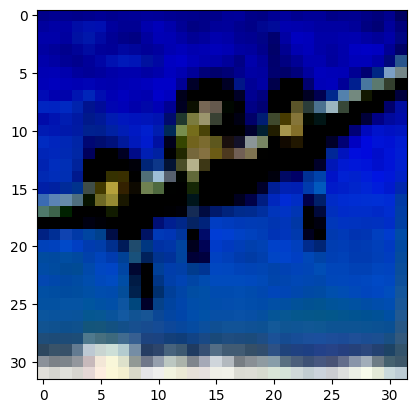

Label: 0


In [21]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img.permute(1,2,0))
plt.show()
print(f"Label: {label}")

We can check the size of batch size and the number of batches to compute the number of images for training:
- the batch size is 128
- 352 batches


In [22]:
print(train_dataloader.batch_size)
print(len(train_dataloader))
print(len(train_dataloader)*train_dataloader.batch_size)
#print(len(train_dataloader.dataset[-1]) #last batch has fewer images


128
352
45056


#3.Exploring Convolutional Layers

In this exercise, we build a CNN (Convolutional Neural Network) model. This requires using conv2d layers on images. We first explore conv2d layers to better understand how they work. We do the following:

- instantiate a conv2d layers in keras tensorflow
- passing an image through a conv2d layer
- understanding image output size, padding and stride

useful links:

- https://keras.io/api/layers/convolution_layers/convolution2d/
- https://kvirajdatt.medium.com/calculating-output-dimensions-in-a-cnn-for-convolution-and-pooling-layers-with-keras-682960c73870
- https://towardsdatascience.com/types-of-convolutions-in-deep-learning-717013397f4d
- https://towardsdatascience.com/understanding-2d-dilated-convolution-operation-with-examples-in-numpy-and-tensorflow-with-d376b3972b25
-https://www.wolframalpha.com/input?i=floor%5B%28W%2B2*p+-+1*%28k-1%29+-+1%29%2FS%2B1%5D+for+W%3D256%2C+p%3D1%2C+k%3D%7B2%2C3%2C4%7D%2C+S%3D2

Let's instantiate a conv2d layer. Note that we have many parameters availabe:

- filter: number of kernels to run to create output features maps
- kernel_size: kernel size used defined in heightxwidth, typically (3,3)
- stride: the size of the steps when moving the kernel across images in height and width. If (1,1) no pixels are skipped. Input is a single number or tuple.
- padding: if valid there is no padding, if same padding is used to keep the same input size in the output image.
- dilation_rate: create a kernel with dilation (wider receptive field with gaps)
- activation: activation function to apply to feature output map

From torch documentation:

stride controls the stride for the cross-correlation, a single number or a tuple.

padding controls the amount of padding applied to the input. It can be either a string {‘valid’, ‘same’} or an int / a tuple of ints giving the amount of implicit padding applied on both sides.

dilation controls the spacing between the kernel points; also known as the à trous algorithm. It is harder to describe, but this link has a nice visualization of what dilation does.

groups controls the connections between inputs and outputs. in_channels and out_channels must both be divisible by groups. For example,

At groups=1, all inputs are convolved to all outputs.

At groups=2, the operation becomes equivalent to having two conv layers side by side, each seeing half the input channels and producing half the output channels, and both subsequently concatenated.

At groups= in_channels, each input channel is convolved with its own set of filters (of size
out_channels
in_channels
in_channels
out_channels
​
 ).

The parameters kernel_size, stride, padding, dilation can either be:

a single int – in which case the same value is used for the height and width dimension

a tuple of two ints – in which case, the first int is used for the height dimension, and the second int for the width dimension

In [23]:
from torch import nn
conv2D_layer = nn.Conv2d(
          in_channels=3,
          out_channels=8,
          kernel_size=(3,3),
          stride=(1, 1),
          padding="valid",
          dilation=1,
          groups=1,
          bias=True,
          padding_mode='zeros',
          device=None,
          dtype=None)
conv2D_layer

Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=valid)

Let's now select an image to pass throught the layer. Note that we havee an input image of:
- height (row):32
- width (col): 32
- channel: 3

In [24]:
image_example = train_dataset.data[0]
#loader[0,:,:,:]
print(type(image_example))
image_example.shape

<class 'numpy.ndarray'>


(32, 32, 3)

<class 'numpy.ndarray'>
(32, 32, 3)


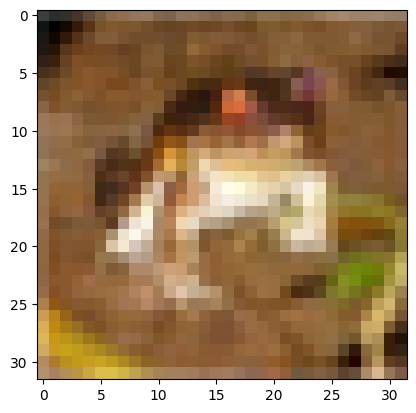

In [25]:
print(type(image_example)) #check that the data type is numpy array
print(image_example.shape) #selecting sample 0
plt.imshow(image_example)

We need a 4 dimensional tensor to pass the image through the conv2d layer, so we add a dimension 1 with axis 0. This represent the sample dimension. In this case, we only hae one sample.

In [26]:
image_example = np.expand_dims(image_example, axis=0)
print(image_example.dtype)
image_example.shape

uint8


(1, 32, 32, 3)

The output of the conv2d layer is a 4 dimensional tensor with 8 channels corresponding to the new feature generated.

In [27]:
image_output = conv2D_layer((torch.from_numpy(image_example).permute(0,3,1,2).float()))
image_output.shape

torch.Size([1, 8, 30, 30])

Notice that we lost 2 pixels on height (row) and width (column) because we set the padding to valid so that there is no padding. The general formula for number of pixels loss based on the size of the filter is:

- i = image size (assuming square image)
- k = filter size (assuming square filter)
- p = padding
- s = stride

**Case 1**: no padding and stride 1

- output size = i - k + 1 = 32 - 3 + 1 = 30
- output size = i - k + 1 = 32 - 5 + 1 = 28

**Case 2**: padding and stride

output size = ((i - k + 2 * p) /s ) + 1



In [28]:
from torch import nn
conv2D_layer = nn.Conv2d(
          in_channels=3,
          out_channels=8,
          kernel_size=(5,5),
          stride=(2, 2),
          padding="valid",
          dilation=1,
          groups=1,
          bias=True,
          padding_mode='zeros',
          device=None,
          dtype=None)

image_output = conv2D_layer(torch.from_numpy(image_example).permute(0,3,1,2).float())
image_output.shape

torch.Size([1, 8, 14, 14])

# 4.Building and training Models

We will be using the sequential api to build the CNN model to classify the 10 CIFAR classes.
We will compare 3 model architectures:

1. model_dnn: A DNN model using a flatten layer without any CNN layer.
2. model_lenet5: The Lenet 5 model, a famous CNN model introduced by Yann Lecun.
3. model_cnn: A more complex and recent and CNN architecture using the relu function and some drop out layers.

links:
- https://towardsdatascience.com/introduction-to-pytorch-from-training-loop-to-prediction-a70372764432/


## 4.1 Build a Dense Neural Network for CIFAR

First, we will use a fully connected network also called dense network because every node in successive layers are connected to the next and previous layers.
This can result in a large number of parameters even with a very simple architecture.

In [29]:
INPUT_SHAPE = (3,32,32)
print(INPUT_SHAPE)
INPUT_SHAPE[0]*INPUT_SHAPE[1]*INPUT_SHAPE[2]

(3, 32, 32)


3072

In [30]:
#from torch import nn
import torch.nn.functional as F

#input_size = INPUT_SHAPE
output_size = num_classes #corresponding to 10 CIFAR classes

class Modeldnn(nn.Module):
    def __init__(self,input_size,output_size,name):
        super().__init__()
        self.name = name
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size[0]*input_size[1]*input_size[2], 512) #should be calculated automatically from inputs
        self.fc2 = nn.Linear(512, output_size)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = F.relu(x)
        out = self.fc2(x)
        #out = F.softmax(x)
        return out


https://medium.com/the-owl/how-to-get-model-summary-in-pytorch-57db7824d1e3

https://pytorch.org/tutorials/beginner/introyt/trainingyt.html


In [31]:
from torchsummary import summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_dnn = Modeldnn(input_size=INPUT_SHAPE,output_size=num_classes,name='model_dnn').to(device)
summary(model_dnn, input_size = (3, 32, 32), batch_size = -1)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                 [-1, 3072]               0
            Linear-2                  [-1, 512]       1,573,376
            Linear-3                   [-1, 10]           5,130
Total params: 1,578,506
Trainable params: 1,578,506
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.03
Params size (MB): 6.02
Estimated Total Size (MB): 6.06
----------------------------------------------------------------


- https://shonit2096.medium.com/cnn-on-cifar10-data-set-using-pytorch-34be87e09844
- https://medium.com/swlh/cross-entropy-loss-in-pytorch-c010faf97bab


In [32]:
(model_dnn.state_dict().keys())

odict_keys(['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias'])

In [33]:
#took 10 minutes for 30 epochs

#seed_value = 42
#torch.manual_seed(seed_value) #for training reproducibiligy
#np.random.seed(seed_value) #for GPU and CPU operations reproducibliy

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_dnn.parameters(), lr=0.01)

# 4. Training loop
epochs = 2
train_loss_list = []
list_df_train_loss = []
list_df_loss = []
list_batch_number = []
for epoch in range(epochs):
  model_dnn.train(True) # Set model to training mode
  train_loss = 0.0
  for batch_val, data in enumerate(train_dataloader):
    inputs, labels = data
    # Zero the gradients
    optimizer.zero_grad()
    # Forward pass
    outputs = model_dnn(inputs)
    # Calculate loss
    loss = loss_fn(outputs, labels)
    # Backward pass and optimization
    loss.backward()
    optimizer.step() #update the weights
    train_loss  += loss.item()
    df_loss_val = pd.DataFrame({'batch_number':[batch_val],
                            'loss':[loss.item()],
                            'epoch': [epoch]})
    list_df_loss.append(df_loss_val)

  df_train_loss_val = pd.DataFrame({'train_loss':[train_loss],
                                'epoch': [epoch]})
  train_loss_list.append(train_loss)
  list_df_train_loss.append(df_train_loss_val)
  print(f'Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}')
#maybe add validation
df_train_loss = pd.concat(list_df_train_loss)
df_loss = pd.concat(list_df_loss).reset_index(drop=True)
df_train_loss
df_loss

Epoch 1/2, Loss: 1036.8148
Epoch 2/2, Loss: 1198.9014


,batch_number,loss,epoch
0,0,2.3042,0
1,1,9.2742,0
2,2,9.5828,0
3,3,13.4011,0
4,4,10.5617,0
...,...,...,...
699,347,3.4040,1
700,348,3.2157,1
701,349,3.5509,1
702,350,3.7706,1


In [34]:
def train_model(model,epochs,train_dataloader):

  #took 10 minutes for 30 epochs

  #seed_value = 42
  #torch.manual_seed(seed_value) #for training reproducibiligy
  #np.random.seed(seed_value) #for GPU and CPU operations reproducibliy

  loss_fn = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

  # 4. Training loop
  #epochs = 30
  train_loss_list = []
  list_df_train_loss = []
  list_df_loss = []
  list_batch_number = []
  for epoch in range(epochs):
    model.train(True) # Set model to training mode
    train_loss = 0.0
    for batch_val, data in enumerate(train_dataloader):
      inputs, labels = data
      # Zero the gradients
      optimizer.zero_grad()
      # Forward pass
      outputs = model(inputs)
      # Calculate loss
      loss = loss_fn(outputs, labels)
      # Backward pass and optimization
      loss.backward()
      optimizer.step() #update the weights
      train_loss  += loss.item()
      df_loss_val = pd.DataFrame({'batch_number':[batch_val],
                              'loss':[loss.item()],
                              'epoch': [epoch]})
      list_df_loss.append(df_loss_val)

    df_train_loss_val = pd.DataFrame({'train_loss':[train_loss],
                                  'epoch': [epoch]})
    train_loss_list.append(train_loss)
    list_df_train_loss.append(df_train_loss_val)
    #print(f'Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}')
    #list_df_train_loss
    print(f'Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}')
  #maybe add validation
  df_train_loss = pd.concat(list_df_train_loss)
  df_loss = pd.concat(list_df_loss).reset_index(drop=True)
  #df_train_loss
  #df_loss

  return df_train_loss,df_loss,model


In [35]:
df_loss.groupby('epoch')['loss'].sum()

,loss
epoch,
0,1036.8148
1,1198.9014


We can save the loss inoformation and model weights at the end of the training.

In [36]:
model_name = model_dnn.name
loss_df = pd.concat(list_df_loss)
# save to csv:
loss_csv_file = 'loss_'+model_name+'_'+out_suffix+'.csv'
loss_df.to_csv(loss_csv_file,index=False)
#save model in
output_model_filename = f'{model_name}_{out_suffix}.pth'
torch.save(model_dnn.state_dict(), os.path.join(out_dir,output_model_filename))

In [37]:
!ls -ltr

total 15893
drwx------ 3 root root    4096 Mar  1 01:30 data
-rw------- 1 root root   17215 Mar  1 21:16 loss_model_lenet5_intro_to_cnn_pytorch_20250301.csv
-rw------- 1 root root  252706 Mar  1 21:16 model_lenet5_intro_to_cnn_pytorch_20250301.pth
-rw------- 1 root root   17069 Mar  1 21:33 loss_model_cnn_intro_to_cnn_pytorch_20250301.csv
-rw------- 1 root root 9588518 Mar  1 21:33 model_cnn_intro_to_cnn_pytorch_20250301.pth
-rw------- 1 root root   59176 Mar  1 22:11 CNN_model_training_loss_comparison_intro_to_cnn_pytorch_20250301.png
-rw------- 1 root root   17035 Mar  2 19:07 loss_model_dnn_intro_to_cnn_pytorch_20250301.csv
-rw------- 1 root root 6316496 Mar  2 19:07 model_dnn_intro_to_cnn_pytorch_20250301.pth


##4.2 Building the Lenet CNN model

Lenet5 is named after Yann Lecun, one of the 'father' of Deep Learning. It is one of the first model with a Convolutional Neural Network architecture.
LeNet-5 contains 5 layers including 2 convolutional hidden layers (followed by averaged pooling) and 2 fully connected hidden layer.

![lenet.png](https://raw.githubusercontent.com/MostafaGazar/mobile-ml/master/files/lenet.png)
LeNet-5 Architecture. Credit: [LeCun et al., 1998](http://yann.lecun.com/exdb/publis/psgz/lecun-98.ps.gz)

In [38]:
import torch.nn as nn
import torch.nn.functional as F
print(INPUT_SHAPE)
input_size = INPUT_SHAPE[0] #three channels because RGB image
output_size = num_classes

class LeNet(nn.Module):
    def __init__(self,input_size,output_size,name):
        super().__init__()

        self.name = name
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_size, out_channels=6, kernel_size=(5,5), stride=(1, 1), padding="valid"), #6x28x28
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=(2, 2), stride=None) #6x14x14
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=(5,5), stride=(1, 1), padding="valid"), #16x10x10
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=(2, 2), stride=None) #16x5x5
        )#16x26x26
        self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=16*5*5, out_features=120),
        nn.ReLU(),
        nn.Linear(in_features=120, out_features=84),
        nn.ReLU(),
        nn.Linear(in_features=84, out_features=output_size),
        )
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        #x = F.softmax(x)
        return x

model_LeNet = LeNet(input_size=input_size,output_size=num_classes,name='model_lenet5').to(device)
summary(model_LeNet, input_size = (3, 32, 32), batch_size = -1)


(3, 32, 32)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]             456
              Tanh-2            [-1, 6, 28, 28]               0
         AvgPool2d-3            [-1, 6, 14, 14]               0
            Conv2d-4           [-1, 16, 10, 10]           2,416
              Tanh-5           [-1, 16, 10, 10]               0
         AvgPool2d-6             [-1, 16, 5, 5]               0
           Flatten-7                  [-1, 400]               0
            Linear-8                  [-1, 120]          48,120
              ReLU-9                  [-1, 120]               0
           Linear-10                   [-1, 84]          10,164
             ReLU-11                   [-1, 84]               0
           Linear-12                   [-1, 10]             850
Total params: 62,006
Trainable params: 62,006
Non-trainable params: 0
---------------------

In [39]:
'''
df_train_loss2,df_loss2,model_LeNet2 = train_model(model=model_LeNet,
                                             #loss_fn=loss_fn,
                                             #optimizer=optimizer
                                             epochs=30,
                                             train_dataloader=train_dataloader)
'''

'\ndf_train_loss2,df_loss2,model_LeNet2 = train_model(model=model_LeNet,\n                                             #loss_fn=loss_fn,\n                                             #optimizer=optimizer\n                                             epochs=30,\n                                             train_dataloader=train_dataloader)\n'

In [40]:
#took 11 minutes for 30 epochs

#seed_value = 42
#torch.manual_seed(seed_value) #for training reproducibiligy
#np.random.seed(seed_value) #for GPU and CPU operations reproducibliy

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_LeNet.parameters(), lr=0.01)

# 4. Training loop
epochs = 2
train_loss_list = []
list_df_train_loss = []
list_df_loss = []
list_batch_number = []
for epoch in range(epochs):
  model_LeNet.train(True) # Set model to training mode
  train_loss = 0.0
  for batch_val, data in enumerate(train_dataloader):
    inputs, labels = data
    # Zero the gradients
    optimizer.zero_grad()
    # Forward pass
    outputs = model_LeNet(inputs)
    # Calculate loss
    loss = loss_fn(outputs, labels)
    # Backward pass and optimization
    loss.backward()
    optimizer.step() #update the weights
    train_loss  += loss.item()
    df_loss_val = pd.DataFrame({'batch_number':[batch_val],
                            'loss':[loss.item()],
                            'epoch': [epoch]})
    list_df_loss.append(df_loss_val)

  df_train_loss_val = pd.DataFrame({'train_loss':[train_loss],
                                'epoch': [epoch]})
  train_loss_list.append(train_loss)
  list_df_train_loss.append(df_train_loss_val)
  #print(f'Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}')
  #list_df_train_loss
  print(f'Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}')
#maybe add validation
df_train_loss = pd.concat(list_df_train_loss)
df_loss = pd.concat(list_df_loss).reset_index(drop=True)
df_train_loss
df_loss

Epoch 1/2, Loss: 606.6018
Epoch 2/2, Loss: 534.4191


,batch_number,loss,epoch
0,0,2.3133,0
1,1,2.2859,0
2,2,2.3340,0
3,3,2.1918,0
4,4,2.2465,0
...,...,...,...
699,347,1.5723,1
700,348,1.4075,1
701,349,1.6846,1
702,350,1.4556,1


In [41]:
df_loss.groupby('epoch')['loss'].sum()

,loss
epoch,
0,606.6018
1,534.4191


In [42]:
model_name = model_LeNet.name
print(model_name)
loss_df = pd.concat(list_df_loss)
# save to csv:
loss_csv_file = 'loss_'+model_name+'_'+out_suffix+'.csv'
loss_df.to_csv(loss_csv_file,index=False)
# serialize weights to HDF5
output_model_filename = f'{model_name}_{out_suffix}.pth'
torch.save(model_LeNet.state_dict(), os.path.join(out_dir,output_model_filename))

model_lenet5


##4.3 Building a more complex CNN model

In [43]:
#del model_cnn

In [44]:
import torch.nn as nn
import torch.nn.functional as F
#parameters:
print(INPUT_SHAPE)
num_classes =10
input_size = INPUT_SHAPE[0] #three channels because RGB image
output_size = num_classes

class modelCNN(nn.Module):
    def __init__(self,input_size,output_size,name):
        super().__init__()


        self.name = name
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_size, out_channels=32, kernel_size=(3,3), stride=(1, 1), padding="same"), #32x322x32
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3,3), stride=(1, 1), padding="same"), #32x32x32
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2), stride=None) #32x16x16
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3,3), stride=(1, 1), padding="same"), #64x16x16
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3,3), stride=(1, 1), padding="same"), #64x16x16
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2), stride=None) #64x8x8
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(3,3), stride=(1, 1), padding="same"), #128x8x8
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=(3,3), stride=(1, 1), padding="same"), #128x8x8
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2), stride=None) #128x4x4
        )

        self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Dropout(0.2),
        nn.Linear(in_features=128*4*4, out_features=1024),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(in_features=1024, out_features=output_size),
        )
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.classifier(x)
        #x = F.softmax(x)
        return x
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_cnn = modelCNN(input_size=input_size,output_size=num_classes,name='model_cnn').to(device)
summary(model_cnn, input_size = (3, 32, 32), batch_size = -1)


(3, 32, 32)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
              ReLU-2           [-1, 32, 32, 32]               0
            Conv2d-3           [-1, 32, 32, 32]           9,248
              ReLU-4           [-1, 32, 32, 32]               0
         MaxPool2d-5           [-1, 32, 16, 16]               0
            Conv2d-6           [-1, 64, 16, 16]          18,496
              ReLU-7           [-1, 64, 16, 16]               0
            Conv2d-8           [-1, 64, 16, 16]          36,928
              ReLU-9           [-1, 64, 16, 16]               0
        MaxPool2d-10             [-1, 64, 8, 8]               0
           Conv2d-11            [-1, 128, 8, 8]          73,856
             ReLU-12            [-1, 128, 8, 8]               0
           Conv2d-13            [-1, 128, 8, 8]         147,584
             ReLU-14       

In [45]:
#took 45 minutes for 15 epochs

#seed_value = 42
#torch.manual_seed(seed_value) #for training reproducibiligy
#np.random.seed(seed_value) #for GPU and CPU operations reproducibliy

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.01)

# 4. Training loop
epochs = 2
train_loss_list = []
list_df_train_loss = []
list_df_loss = []
list_batch_number = []
for epoch in range(epochs):
  model_cnn.train(True) # Set model to training mode
  train_loss = 0.0
  for batch_val, data in enumerate(train_dataloader):
    inputs, labels = data
    # Zero the gradients
    optimizer.zero_grad()
    # Forward pass
    outputs = model_cnn(inputs)
    # Calculate loss
    loss = loss_fn(outputs, labels)
    # Backward pass and optimization
    loss.backward()
    optimizer.step() #update the weights
    train_loss  += loss.item()
    df_loss_val = pd.DataFrame({'batch_number':[batch_val],
                            'loss':[loss.item()],
                            'epoch': [epoch]})
    list_df_loss.append(df_loss_val)

  df_train_loss_val = pd.DataFrame({'train_loss':[train_loss],
                                'epoch': [epoch]})
  train_loss_list.append(train_loss)
  list_df_train_loss.append(df_train_loss_val)
  #print(f'Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}')
  #list_df_train_loss
  print(f'Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}')
#maybe add validation
df_train_loss = pd.concat(list_df_train_loss)
df_loss = pd.concat(list_df_loss).reset_index(drop=True)
df_train_loss
df_loss

Epoch 1/2, Loss: 716.0892
Epoch 2/2, Loss: 604.2158


,batch_number,loss,epoch
0,0,2.2995,0
1,1,31.6573,0
2,2,2.3302,0
3,3,2.3266,0
4,4,2.3339,0
...,...,...,...
699,347,1.7656,1
700,348,1.6500,1
701,349,1.6705,1
702,350,1.6561,1


In [46]:
df_loss.groupby('epoch')['loss'].sum()

,loss
epoch,
0,716.0892
1,604.2158


In [47]:
model_name = model_cnn.name
print(model_name)
loss_df = pd.concat(list_df_loss)
# save to csv:
loss_csv_file = 'loss_'+model_name+'_'+out_suffix+'.csv'
loss_df.to_csv(loss_csv_file,index=False)
output_model_filename = f'{model_name}_{out_suffix}.pth'
torch.save(model_cnn.state_dict(), os.path.join(out_dir,output_model_filename))

model_cnn


#5.Training models


links:

- https://medium.com/@merilainen.vili/save-and-load-models-to-disk-in-pytorch-python-a-complete-guide-a667057b511c


In [49]:
print(device)
del model_dnn
del model_LeNet
del model_cnn

model_dnn = Modeldnn(input_size=INPUT_SHAPE,output_size=num_classes,name='model_dnn').to(device)
model_LeNet = LeNet(input_size=input_size,output_size=num_classes,name='model_lenet5').to(device)
model_cnn = modelCNN(input_size=input_size,output_size=num_classes,name='model_cnn').to(device)
list_models=[model_dnn,model_LeNet,model_cnn] #use the model
list_models

cpu


[Modeldnn(
   (flatten): Flatten(start_dim=1, end_dim=-1)
   (fc1): Linear(in_features=3072, out_features=512, bias=True)
   (fc2): Linear(in_features=512, out_features=10, bias=True)
 ),
 LeNet(
   (conv_block1): Sequential(
     (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1), padding=valid)
     (1): Tanh()
     (2): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0)
   )
   (conv_block2): Sequential(
     (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1), padding=valid)
     (1): Tanh()
     (2): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0)
   )
   (classifier): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=400, out_features=120, bias=True)
     (2): ReLU()
     (3): Linear(in_features=120, out_features=84, bias=True)
     (4): ReLU()
     (5): Linear(in_features=84, out_features=10, bias=True)
   )
 ),
 modelCNN(
   (conv_block1): Sequential(
     (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
     (

In [52]:
## Loop through this
#seed_value = 42
#torch.manual_seed(seed_value) #for training reproducibiligy
#np.random.seed(seed_value) #for GPU and CPU operations reproducibliy

list_models=[model_dnn,model_LeNet,model_cnn] #use the model

list_model_loss_df=[]
epochs = 30
batch_size = 128

if run_model==True:

  for model in list_models:
  #if run_model=True then train model and store weights and history

    # train/Fit model: takes between 50 and 60 minutes
    model_name = model.name
    print(model_name)
    df_train_loss,df_loss,model = train_model(model=model,
                                             #loss_fn=loss_fn,
                                             #optimizer=optimizer
                                             epochs=30,
                                             train_dataloader=train_dataloader)

    # save to csv:
    df_loss.to_csv(loss_csv_file, index=False)
    output_model_filename = f'{model_name}_{out_suffix}.pth'
    torch.save(model.state_dict(), os.path.join(out_dir,output_model_filename))
    list_model_loss_df.append(df_loss)

    print("Saved model to disk ", model_name)

  #if run_model=False then load models weights and loss history from h5 file
if run_model==False:
  if model_path is None:
    model_path = out_dir
    #print('Set model path to output directory')

  model_names=['model_dnn','model_lenet5','model_cnn']
  i=0
  for model_name in model_names:
    print(i)
    print(model_name)
    fileglob ="*"+model_name+"*.pth"
    model_path_filename= os.path.join(model_path,fileglob) #classified
    model_path_filename = glob.glob(model_path_filename,recursive=False)[0]
    #model=list_models[i]
    #model.summary()
    print('This is the model path ',model_path_filename)

    list_models[i].load_state_dict(torch.load(model_path_filename)) #loading weights
    fileglob ='*'+model_name+"*.csv"
    loss_model_path = os.path.join(model_path,fileglob)
    loss_model_path = glob.glob(loss_model_path,recursive=False)[0]
    loss_df = pd.read_csv(loss_model_path)
    list_model_loss_df.append(loss_df)
    print(f'Loading weight completed for {model_name}')
    i=i+1
    #del model

model_dnn
Epoch 1/30, Loss: 1040.1057
Epoch 2/30, Loss: 1247.3148
Epoch 3/30, Loss: 1040.3485
Epoch 4/30, Loss: 1100.0765
Epoch 5/30, Loss: 1040.8560
Epoch 6/30, Loss: 1011.1865
Epoch 7/30, Loss: 1197.5757
Epoch 8/30, Loss: 994.6268
Epoch 9/30, Loss: 920.8060
Epoch 10/30, Loss: 978.8954
Epoch 11/30, Loss: 951.4646
Epoch 12/30, Loss: 1020.5755
Epoch 13/30, Loss: 904.9652
Epoch 14/30, Loss: 911.8356
Epoch 15/30, Loss: 945.5615
Epoch 16/30, Loss: 967.3888
Epoch 17/30, Loss: 935.9254
Epoch 18/30, Loss: 886.2928
Epoch 19/30, Loss: 790.9367
Epoch 20/30, Loss: 988.6471
Epoch 21/30, Loss: 878.7208
Epoch 22/30, Loss: 874.7421
Epoch 23/30, Loss: 796.6257
Epoch 24/30, Loss: 821.4592
Epoch 25/30, Loss: 978.2770
Epoch 26/30, Loss: 856.3135
Epoch 27/30, Loss: 761.8491
Epoch 28/30, Loss: 811.0065
Epoch 29/30, Loss: 952.5678
Epoch 30/30, Loss: 807.7853
Saved model to disk  model_dnn
model_lenet5
Epoch 1/30, Loss: 606.1754
Epoch 2/30, Loss: 534.3989
Epoch 3/30, Loss: 499.9077
Epoch 4/30, Loss: 474.0197

In [53]:
list_models

[Modeldnn(
   (flatten): Flatten(start_dim=1, end_dim=-1)
   (fc1): Linear(in_features=3072, out_features=512, bias=True)
   (fc2): Linear(in_features=512, out_features=10, bias=True)
 ),
 LeNet(
   (conv_block1): Sequential(
     (0): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1), padding=valid)
     (1): Tanh()
     (2): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0)
   )
   (conv_block2): Sequential(
     (0): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1), padding=valid)
     (1): Tanh()
     (2): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0)
   )
   (classifier): Sequential(
     (0): Flatten(start_dim=1, end_dim=-1)
     (1): Linear(in_features=400, out_features=120, bias=True)
     (2): ReLU()
     (3): Linear(in_features=120, out_features=84, bias=True)
     (4): ReLU()
     (5): Linear(in_features=84, out_features=10, bias=True)
   )
 ),
 modelCNN(
   (conv_block1): Sequential(
     (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
     (

Now let's take a look at the loss and accuracy for the training of the three models. For each epoch, keras computes a loss and accuracy metrics. We extracted these informations for the callback keras object in the previous step during the fitting process.

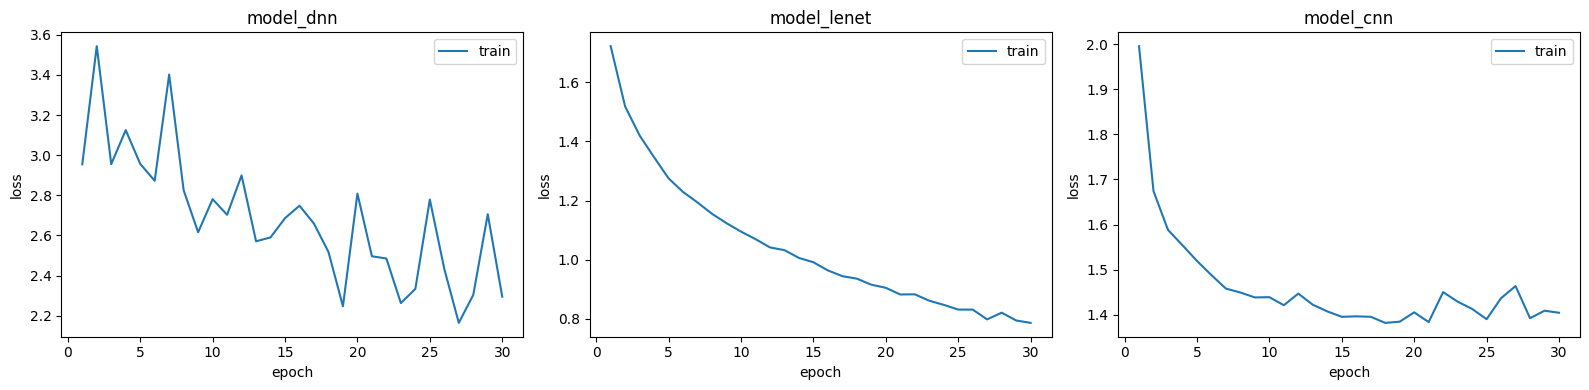

In [96]:
num_models=3
fig, ax = plt.subplots(1,num_models,figsize=(16,4))
model_names=['model_dnn','model_lenet','model_cnn']
plot_col = 'mean_loss'
#plot_col = 'sum_loss'

for model_val in range(num_models):
  df_loss_agg = list_model_loss_df[model_val]
  df_loss_agg = (df_loss_agg.groupby('epoch')
                     .agg({'loss':['mean','sum']})
                     .set_axis(['mean_loss','sum_loss'],axis=1)
                     .reset_index()
                     )
  df_loss_agg['loss']= round(df_loss_agg[plot_col],4)
  #hist_df=list_hist_df[model_val]
  df_loss_agg['epoch']=np.arange(1,epochs+1)
  ax[model_val].ticklabel_format(useOffset=False)
  ax[model_val].plot(df_loss_agg['epoch'].values,
                     df_loss_agg['loss'].values,
                     label='train')
  #ax[model_val].plot(hist_df['epoch'],hist_df['val_accuracy'],label='val')
  ax[model_val].set_title(model_names[model_val])
  ax[model_val].set_xlabel('epoch')
  ax[model_val].set_ylabel('loss')
  ax[model_val].legend()

fig.tight_layout()
plt.savefig(f'CNN_model_training_loss_comparison_{out_suffix}.png')

We repeat the same steps for loss. Note that this could be turned into a function to avoid copying similar code.

#6.Accurary Assessment and models comparison

We assess models using the test data. The steps as follow:

1. generate test samples and predict using each model
2. compute accuracy metrics
3. compare models using metrics and complexity.

In #1, we generate predictions using the test samples or the model_dnn, model_lenet and model_cnn.

In #2, we use the soft and hard predictions to generate confusion metrics and accuracy metrics such as AUC and precision, recall.

In #3, we compare the three models using the metrics as well as number of parameters (as proxy for model complexity).

In [56]:
#getting the first batch out of data loader
test_dataloader_iter = iter(test_dataloader)
test_image_batch, test_labels_batch = next(test_dataloader_iter)
print(test_image_batch.shape)
print(test_labels_batch.shape)

torch.Size([128, 3, 32, 32])
torch.Size([128])


torch.Size([1, 3, 32, 32])


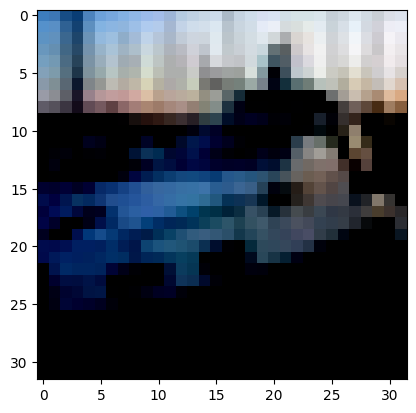

In [57]:
test_image =test_image_batch[2:3] #select third image test sample
print(test_image.shape)
plt.imshow(test_image[0].permute(1,2,0))

In [58]:
model = list_models[2]
model.eval()
y_score_logits = model(test_image)
print(y_score_logits.shape)
y_scores = nn.Softmax(dim=1)(y_score_logits) #these are the proba
y_scores.sum(dim=1)
print(y_scores)
y_pred_test = torch.argmax(y_scores, dim=1)  # Returns [1, 2]
class_names[y_pred_test]

torch.Size([1, 10])
tensor([[0.3421, 0.1195, 0.0222, 0.0067, 0.0030, 0.0025, 0.0023, 0.0039, 0.3950,
         0.1028]], grad_fn=<SoftmaxBackward0>)


'ship'

In [59]:
df_pred_val = pd.DataFrame(y_scores.detach().numpy())
df_pred_val['y_pred_test'] = y_pred_test
df_pred_val['class_name'] = class_names[y_pred_test]
df_pred_val

,0,1,2,3,4,5,6,7,8,9,y_pred_test,class_name
0,0.3421,0.1195,0.0222,0.0067,0.0030,0.0025,0.0023,0.0039,0.3950,0.1028,8,ship


In [60]:
list_df_pred = []
model.eval() # Set model to avaluation mode
test_loss = 0.0
for batch_val, data in enumerate(test_dataloader):
    inputs, labels = data
    # Zero the gradients
    # Forward pass
    with torch.inference_mode():
      y_score_logits = model(inputs)
      y_scores = nn.Softmax(dim=1)(y_score_logits) #these are the proba
      y_pred_test = torch.argmax(y_scores, dim=1)  # Returns [1, 2]
      #pred_class_name = class_names[y_pred_test]
      df_pred_val = pd.DataFrame(y_scores.detach().numpy())
      df_pred_val['y_pred_test'] = y_pred_test
      df_pred_val['labels'] = labels
      #df_pred_val['class_name'] = class_names[y_pred_test]
      list_df_pred.append(df_pred_val)

y_pred_test_df = pd.concat(list_df_pred)
y_pred_test_df

,0,1,2,3,4,5,6,7,8,9,y_pred_test,labels
0,0.0045,0.0199,0.0337,0.3084,0.0196,0.4078,0.0513,0.0587,0.0748,0.0213,5,3
1,0.0537,0.5613,0.0032,0.0004,0.0007,0.0002,0.0002,0.0006,0.3118,0.0679,1,8
2,0.3421,0.1195,0.0222,0.0067,0.0030,0.0025,0.0023,0.0039,0.3950,0.1028,8,8
3,0.1709,0.0070,0.0608,0.0218,0.0198,0.0236,0.0055,0.0104,0.6646,0.0156,8,0
4,0.0001,0.0001,0.0763,0.2835,0.1689,0.1305,0.3266,0.0137,0.0000,0.0003,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...
11,0.1332,0.0027,0.2747,0.2112,0.0216,0.3008,0.0132,0.0233,0.0156,0.0039,5,8
12,0.0090,0.0031,0.0872,0.1843,0.1439,0.3237,0.1037,0.1380,0.0010,0.0061,5,3
13,0.0271,0.0017,0.1928,0.1586,0.1001,0.3188,0.1192,0.0661,0.0115,0.0041,5,5
14,0.0669,0.1676,0.0361,0.2717,0.0911,0.2072,0.0058,0.0532,0.0836,0.0167,3,1


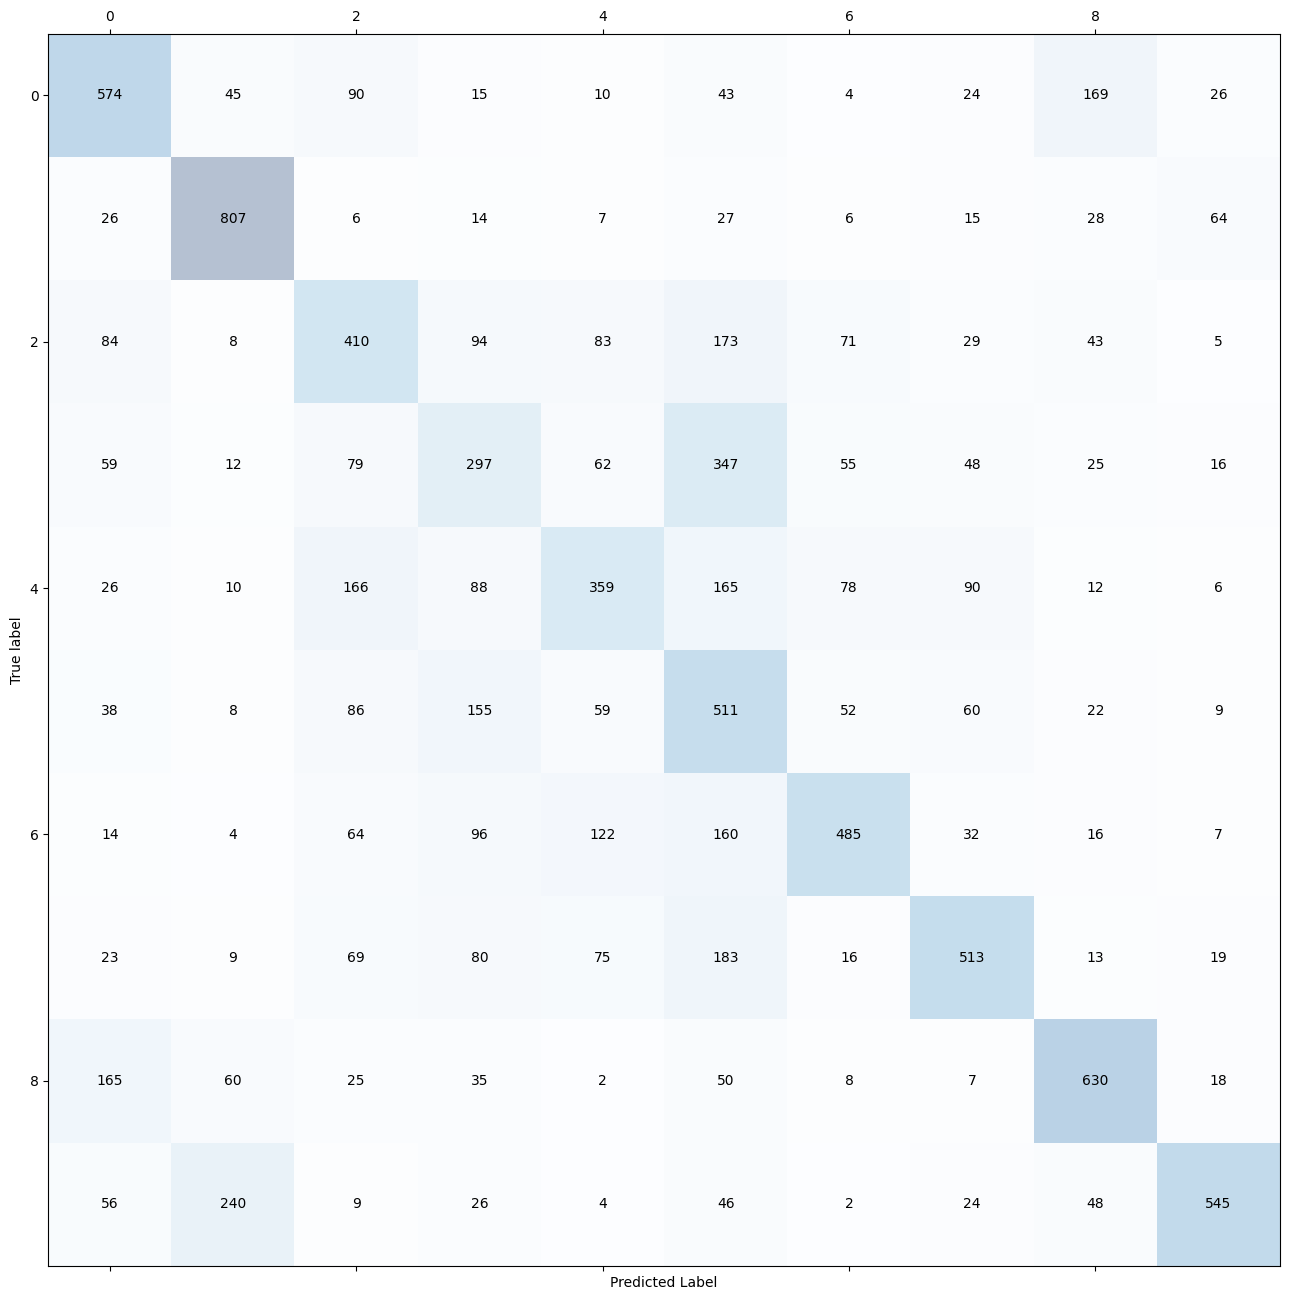

In [61]:
#from sklearn.metrics import classification_report
#from sklearn.metrics import confusion_matrix
y_pred_test = y_pred_test_df['y_pred_test'].values
y_test = y_pred_test_df['labels'].values
report_dict=classification_report(y_test,
                                  y_pred_test,
                                  output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
confusion_matrix_val = confusion_matrix(y_test,y_pred_test)

fig, ax = plt.subplots(figsize=(16,16))
ax.matshow(confusion_matrix_val,cmap=plt.cm.Blues,alpha=0.3)
for i in range(confusion_matrix_val.shape[0]):
  for j in range(confusion_matrix_val.shape[1]):
    ax.text(x=j,y=i,
               s=confusion_matrix_val[i,j],
               va='center',
               ha='center')
    plt.xlabel('Predicted Label')
    plt.ylabel('True label')

In [62]:
report_df
# Note we have 1000 test samples per class
#precision: number of correctly predicted categories out of predictions (True Positive/(True Positive + False Positve))
#recall: (True Positive/(True Positive + False Negative))

,precision,recall,f1-score,support
0,0.5390,0.5740,0.5559,1000.0000
1,0.6708,0.8070,0.7326,1000.0000
2,0.4084,0.4100,0.4092,1000.0000
3,0.3300,0.2970,0.3126,1000.0000
4,0.4585,0.3590,0.4027,1000.0000
5,0.2997,0.5110,0.3778,1000.0000
6,0.6242,0.4850,0.5459,1000.0000
7,0.6093,0.5130,0.5570,1000.0000
8,0.6262,0.6300,0.6281,1000.0000
9,0.7622,0.5450,0.6356,1000.0000


Let's use a function to generate the accuracy metrics for all models.



In [63]:
list_report_df = []
list_pred_test_df = []
for model in list_models:
  report_df, y_pred_test_df = generate_accuracy_assessment(model= model,
                             y_test= None,
                             x_test= None,
                             data_dataloader= test_dataloader,
                             class_names= class_names)
  #report_df = generate_accuracy(model,y_test,x_test,class_names=class_names )
  list_report_df.append(report_df)
  list_pred_test_df.append(y_pred_test_df)
#list_report_df

from functools import reduce
report_df = reduce(lambda df1,df2: df1.merge(df2,"outer"),list_report_df)
report_df

,metric,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck,accuracy,model_name,num_param
0,precision,0.4893,0.4936,0.3496,0.2778,0.3201,0.2934,0.4160,0.4305,0.5258,0.4825,0.4090,model_dnn,1578506
1,precision,0.5390,0.6708,0.4084,0.3300,0.4585,0.2997,0.6242,0.6093,0.6262,0.7622,0.5131,model_cnn,2395434
2,precision,0.5741,0.6892,0.4673,0.3202,0.5069,0.4656,0.5738,0.6753,0.6695,0.6328,0.5504,model_lenet5,62006
3,recall,0.5280,0.5800,0.1580,0.2670,0.5500,0.2080,0.4310,0.4580,0.4680,0.4420,0.4090,model_dnn,1578506
4,recall,0.5740,0.8070,0.4100,0.2970,0.3590,0.5110,0.4850,0.5130,0.6300,0.5450,0.5131,model_cnn,2395434
5,recall,0.6240,0.6920,0.4500,0.4240,0.4790,0.3720,0.6340,0.5720,0.6970,0.5600,0.5504,model_lenet5,62006


A few observations that come out of the assessement:
1. Using results, we can see that it is hard to know if model_cnn or model_lenet5 is performing the best because for some classes Lenet 5 has higher precision (or recall) but the reverse is true for other classes. We would expect that the best model is model_cnn given the large number of parameters. Maybe model_cnn requires longer trainng for its more complex architecture (num_param).
2. There are large variation in the precision and recall among classes.
3.The class with the highest recall is automobile with 0.81 using model cnn. The precision is lower though with 0.67.



#7.Understanding the number of parameters

In this exercise, we produced 3 different architectures with an increasing degree of complexity: DNN,Lenet and Deeper CNN.

DNN is a fully connected neural network (also called dense) because every node in the hidden layers is connected to the previous and next layer. This generates a lof of parameters. If we look at the accuracy table, we can see that we have 1.578 millons parameters even though we only have one hidden layer.Contrast this to Lenet, a five layer network with 4 hidden layers but that only contains 62,006 parameters. The most complex model 'model_cnn' contains 2,395,434 parameters and has 7 hidden layers (max pooling layers have no trained parameters).

In general, going from DNN to CNN, you should see a drop in number of parameters. Let us quickly do a count of parameters for the first and last models used as an example:

**Model_dnn**

In the first architecture we had:

- input layer: 32x32x3 = 3072
- dense 1: 512 nodes
- output: 10 nodes

dense 1: HxWxC x nodes in dense 1 + biases
dense 1: 32x32x3x512+512= 1,573,376

Compare the numbers to the number of parameters in a CNN layer below.

**Model_cnn**

In the third architecture we had:



- conv2d_2: 32x32x32
```
The general structure to count parameters is as follow:
3 input chanels, 32 filters, 3x3 kernels, 32 bias values
channel_in x channel_out x kernel+bias
3x32x3x3+32= 896
```
- conv2d_3: 32x32x32
32x32x3x3+32= 9248

- conv2d_4: 16x16x64
32x64x3x3+64= 18496

- conv2d_5: 16x16x64
64x64x3x3+64= 36928

- conv2d_6: 8x8x128
64x128x3x3+128= 73856

- conv2d_7: 8x8x128
128x128x3x3+128= 147,584

- dense1: 1024
2048x1024+1024= 2,098,176

- dense 6: 10
1024x10+10= 10250

In [64]:
#model_cnn.summary()
summary(model_cnn, input_size = (3, 32, 32), batch_size = -1)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
              ReLU-2           [-1, 32, 32, 32]               0
            Conv2d-3           [-1, 32, 32, 32]           9,248
              ReLU-4           [-1, 32, 32, 32]               0
         MaxPool2d-5           [-1, 32, 16, 16]               0
            Conv2d-6           [-1, 64, 16, 16]          18,496
              ReLU-7           [-1, 64, 16, 16]               0
            Conv2d-8           [-1, 64, 16, 16]          36,928
              ReLU-9           [-1, 64, 16, 16]               0
        MaxPool2d-10             [-1, 64, 8, 8]               0
           Conv2d-11            [-1, 128, 8, 8]          73,856
             ReLU-12            [-1, 128, 8, 8]               0
           Conv2d-13            [-1, 128, 8, 8]         147,584
             ReLU-14            [-1, 12

In [65]:
#model_dnn.summary()
summary(model_dnn, input_size = (3, 32, 32), batch_size = -1)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                 [-1, 3072]               0
            Linear-2                  [-1, 512]       1,573,376
            Linear-3                   [-1, 10]           5,130
Total params: 1,578,506
Trainable params: 1,578,506
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.03
Params size (MB): 6.02
Estimated Total Size (MB): 6.06
----------------------------------------------------------------


#8.Conclusions

In this exercise, we introduced CNN layers for image classification. We used the CIFAR 10 data and predicted the category of each image out of 10 labels. We experimented with the Lenet model and another alternative 10 layers CNN model compared to a fully connected (dense) neural network architecture.

As expected we found that CNN based model outperform fully connected network.  We also found that CNN allows for a substantials reduction of the number of paramaters.

In [ ]:
############################# END OF SCRIPT ###################################